# Dark-photon polarization and lepton reconstruction migration

**Inputs and selections.** Generator-level truth from the canonical
`truth_kinematics_forAN` output (180 v10 signal samples, every file, unweighted).
Polarization uses the strictly-generator channels, **`genOnly`** (status-1 leptons) and
**`genOnly_born`** (status-23), with **no reconstruction, trigger, or vertex
requirements**; they reproduce the `gen_leptons_final`/`gen_leptons_born` channels of the
original study minus the primary-vertex filter. The reconstruction-migration maps use
**`baseNoLj_noTrigger`** (analysis LJ-source object definitions, PV filter, **no HLT**,
so the migration story is trigger-independent) and its `NoLjsource` variant (same, before
the object quality cuts).

The polarization methodology and its full phase-space discussion live in
`signal_kinematics/lepton_kinematics_summary_grid.ipynb`; this notebook reruns the fits
on the canonical full-statistics output and saves the analysis-note figures. The
migration maps fill the note's `fig:reco_lepton_kinematics` reference.


In [1]:
import sys, os, importlib
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy import optimize as opt

here = os.getcwd()
repo = here.split("/sidm")[0]
for p in (repo, os.path.join(repo, "sidm", "studies", "lifetime_study"),
          os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN")):
    if p not in sys.path:
        sys.path.insert(1, p)
from sidm.tools import utilities
import lifetime_analysis as la
import an_style
importlib.reload(la)

utilities.set_plot_style(dpi=110)
CH_FINAL, CH_BORN = "genOnly", "genOnly_born"


In [2]:
from _lifetime_refit import load_truthkin
output = load_truthkin()
print(f"loaded {len(output)} samples")

SAMPLE_GRID = {
    100:  {0.25: "2Mu2E_100GeV_0p25GeV_2p0mm",
           1.2:  "2Mu2E_100GeV_1p2GeV_9p6mm",
           5.0:  "2Mu2E_100GeV_5p0GeV_40p0mm"},
    500:  {0.25: "2Mu2E_500GeV_0p25GeV_0p4mm",
           1.2:  "2Mu2E_500GeV_1p2GeV_1p9mm",
           5.0:  "2Mu2E_500GeV_5p0GeV_8p0mm"},
    1000: {0.25: "2Mu2E_1000GeV_0p25GeV_0p2mm",
           1.2:  "2Mu2E_1000GeV_1p2GeV_0p96mm",
           5.0:  "2Mu2E_1000GeV_5p0GeV_4p0mm"},
}
BS_MASSES = [100, 500, 1000]
ZD_MASSES = [0.25, 1.2, 5.0]
BS_COLORS = {100: "tab:blue", 500: "tab:green", 1000: "tab:red"}

def sample_label(mxx, mzd):
    return rf"$m_{{XX}}={mxx}$, $m_{{Z_d}}={mzd}$ GeV"


loaded 180 samples


## Polarization fits, α summary

For each sample the lepton `|cosθ*|` distribution in the dark-photon rest frame is fit
with `1 + α·cos²θ*` over `[0, 0.8]` (the region free of the extreme-collimation boundary
effect). A spin-1 dark photon decaying to relativistic leptons gives `α → 1` (transverse
polarization); velocity suppression drives `α → 0` as `m_ℓ/m_Zd` grows, visible for
muons at `m_Zd = 0.25 GeV`, where `m_μ` eats half the two-body momentum.


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/polarization_alpha_summary.pdf
  m_XX= 100  m_Zd=0.25  status 1  mu  alpha =  0.171 +- 0.016
  m_XX= 100  m_Zd=0.25  status 1  e   alpha =  0.600 +- 0.085
  m_XX= 100  m_Zd=0.25  status 23 mu  alpha =  0.002 +- 0.074
  m_XX= 100  m_Zd=0.25  status 23 e   alpha =  0.495 +- 0.089
  m_XX= 100  m_Zd=1.20  status 1  mu  alpha =  0.681 +- 0.061
  m_XX= 100  m_Zd=1.20  status 1  e   alpha =  0.654 +- 0.070
  m_XX= 100  m_Zd=1.20  status 23 mu  alpha =  0.554 +- 0.061
  m_XX= 100  m_Zd=1.20  status 23 e   alpha =  0.572 +- 0.082
  m_XX= 100  m_Zd=5.00  status 1  mu  alpha =  0.607 +- 0.072
  m_XX= 100  m_Zd=5.00  status 1  e   alpha =  0.667 +- 0.072
  m_XX= 100  m_Zd=5.00  status 23 mu  alpha =  0.549 +- 0.090
  m_XX= 100  m_Zd=5.00  status 23 e   alpha =  0.491 +- 0.089
  m_XX= 500  m_Zd=0.25  status 1  mu  alpha =  0.252 +- 0.052
  m_XX= 500  m_Zd=0.25  status 1  e   alpha =  0.918 +- 0.048
  m_XX= 50

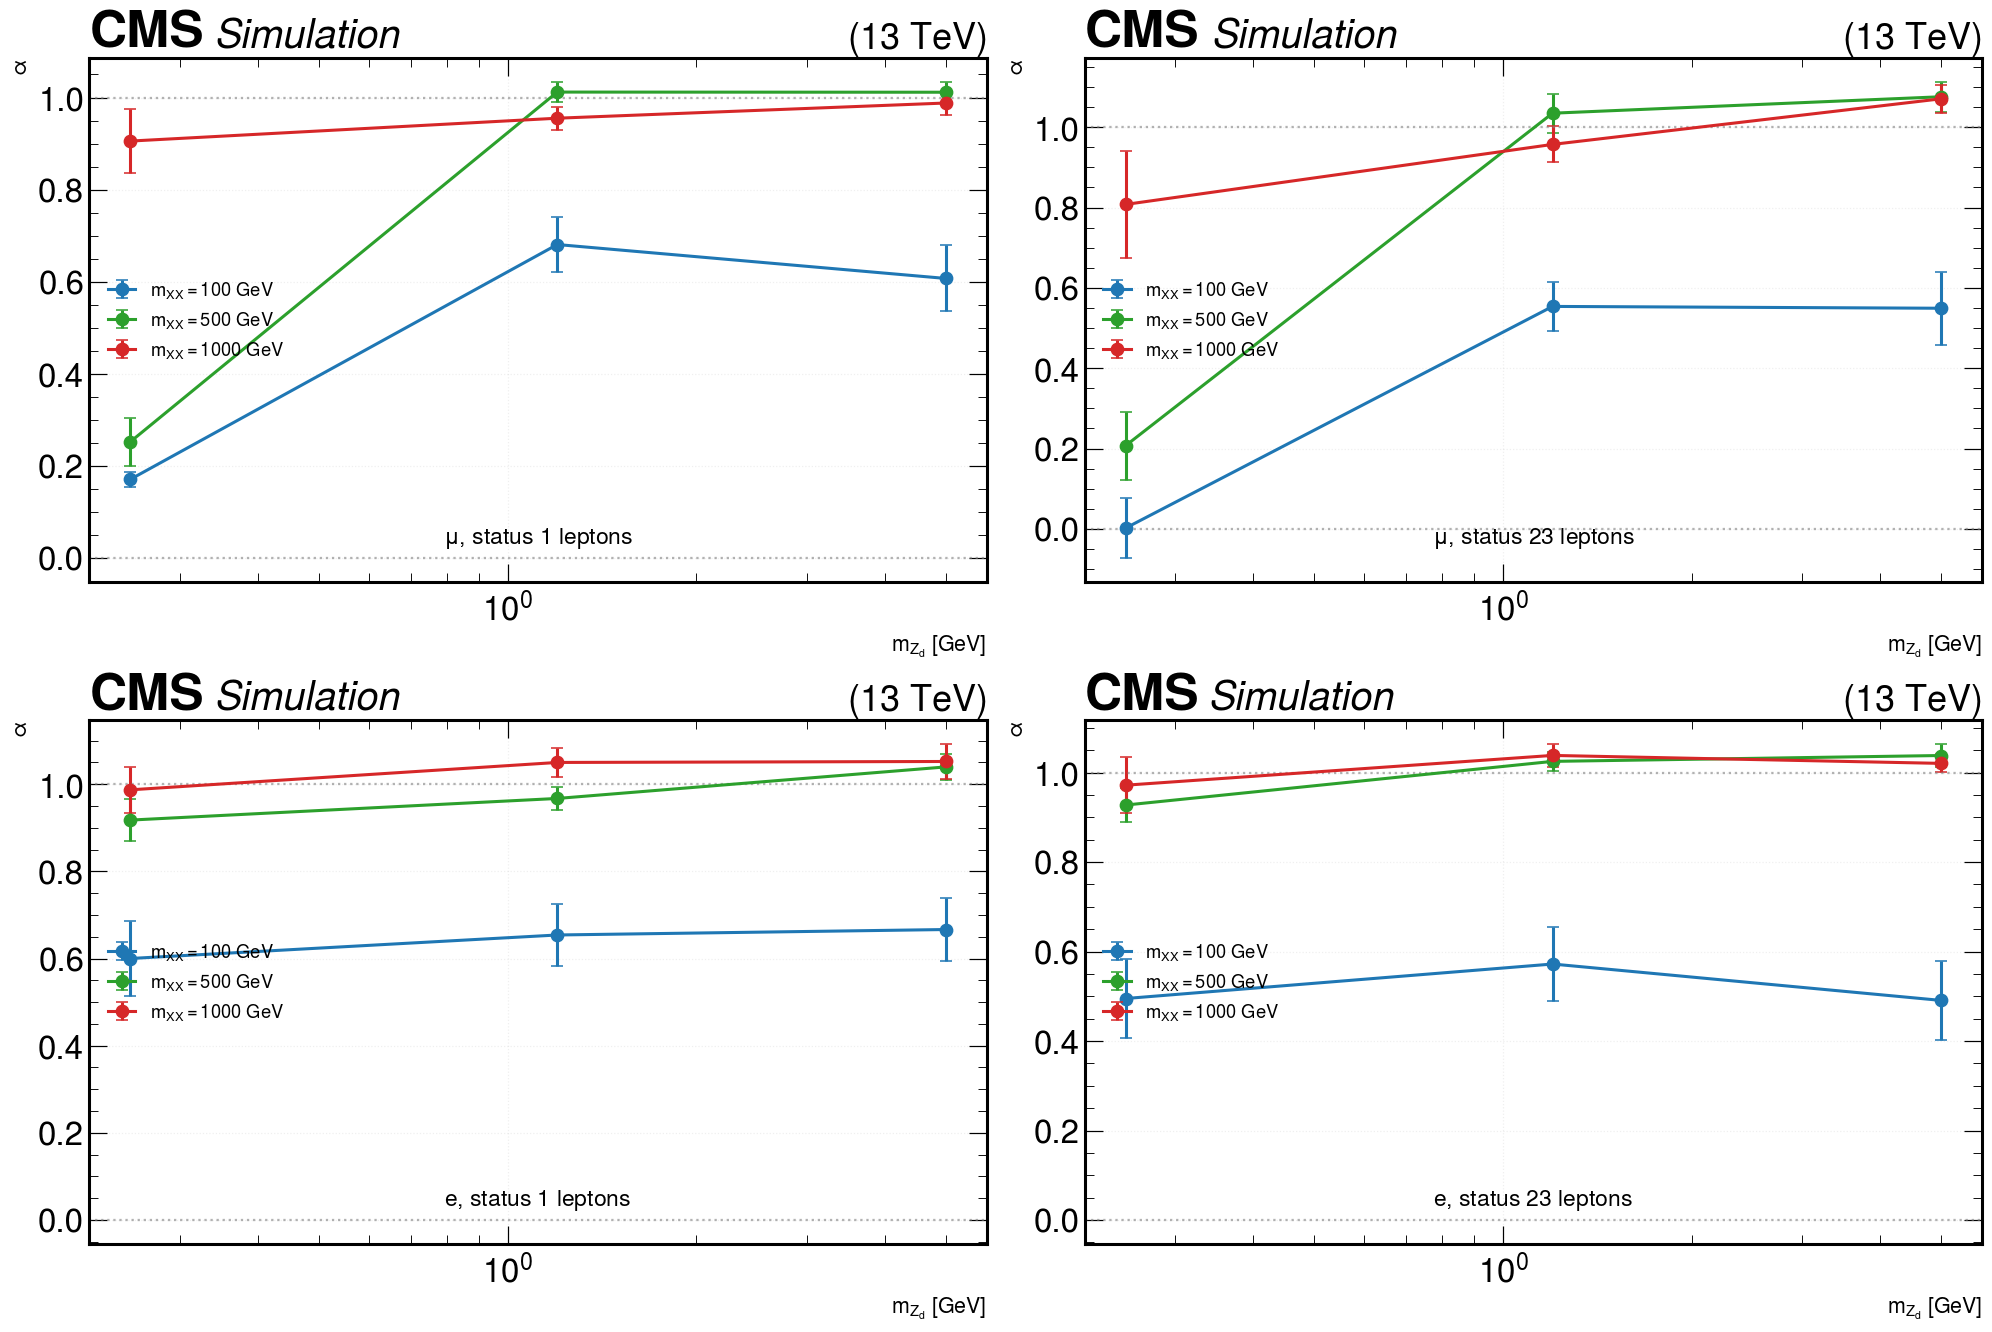

In [3]:
def fit_alpha(h, fit_range=(0.0, 0.8)):
    raw = h.values().flatten().astype(float)
    edges = h.axes[-1].edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    n = min(len(raw), len(centers))
    raw, centers = raw[:n], centers[:n]
    mask = (centers >= fit_range[0]) & (centers <= fit_range[1])
    x, y = centers[mask], raw[mask]
    yerr = np.sqrt(y); yerr[yerr == 0] = 1.0
    def spin1(x, A, alpha): return A * (1 + alpha * x**2)
    try:
        popt, pcov = opt.curve_fit(spin1, x, y, sigma=yerr, p0=[max(y.max(), 1), 0.5])
        return popt[1], float(np.sqrt(np.diag(pcov))[1])
    except Exception:
        return np.nan, np.nan

rows = []
for mxx in BS_MASSES:
    for mzd in ZD_MASSES:
        sample = SAMPLE_GRID[mxx][mzd]
        for status_label, ch in [("status 1", CH_FINAL), ("status 23", CH_BORN)]:
            for flavor, hname in [("mu", "genMu_AFrame_absCosTheta"),
                                  ("e",  "genE_AFrame_absCosTheta")]:
                a, da = fit_alpha(output[sample]["hists"][hname][{"channel": ch}])
                rows.append((mxx, mzd, status_label, flavor, a, da))

fig, axes = plt.subplots(2, 2, figsize=(18, 12), layout="constrained")
for r, flavor in enumerate(["mu", "e"]):
    for c, status in enumerate(["status 1", "status 23"]):
        ax = axes[r, c]
        for mxx in BS_MASSES:
            pts = [(mzd, a, da) for (b, mzd, s, f, a, da) in rows
                   if b == mxx and s == status and f == flavor]
            ax.errorbar([p[0] for p in pts], [p[1] for p in pts],
                        yerr=[p[2] for p in pts], marker="o", markersize=8,
                        color=BS_COLORS[mxx], label=rf"$m_{{XX}}={mxx}$ GeV",
                        capsize=4, linewidth=2)
        ax.axhline(1.0, color="grey", linestyle=":", alpha=0.6)
        ax.axhline(0.0, color="grey", linestyle=":", alpha=0.6)
        flv = r"\mu" if flavor == "mu" else "e"
        ax.set_xlabel(r"$m_{Z_d}$ [GeV]", fontsize=14)
        ax.set_ylabel(r"$\alpha$", fontsize=14)
        ax.set_xscale("log")
        ax.text(0.5, 0.06, rf"${flv}$, {status} leptons", transform=ax.transAxes,
                ha="center", va="bottom", fontsize=15)
        ax.grid(True, alpha=0.2)
        ax.legend(loc="center left", fontsize=12)
        hep.cms.label(ax=ax, data=False)
an_style.save(fig, "polarization_alpha_summary")
for row in rows:
    print("  m_XX=%4d  m_Zd=%.2f  %-9s %-2s  alpha = %6.3f +- %.3f" % row)


**Reading the summary.** In the heavier corner of the grid (`m_XX ≥ 500 GeV`,
`m_Zd ≥ 1.2 GeV`) all four panels recover transverse polarization, with fitted values
`α ≈ 0.96–1.08`, consistent with 1 given the restricted fit range.
Muons at `m_Zd = 0.25 GeV` show the velocity suppression, down to `α ≈ 0` at
`m_XX = 100 GeV`. The suppression pattern is not purely a lepton-mass effect, however:
the entire `m_XX = 100 GeV` row sits below 1 for electrons as well (`α ≈ 0.5–0.7`),
where velocity suppression cannot act. The likely cause is the production gen filter:
its per-lepton `pT > 5 GeV` requirement bites hardest at the lightest bound-state mass
and preferentially removes asymmetric (large `|cosθ*|`) decays, and this row should be
read with that acceptance sculpting in mind. In the hyper-boosted corner
(`m_XX = 1000`, `m_Zd = 0.25`) the restricted fit range keeps the known
extreme-collimation boundary effect out of the fit; the fitted values there are
`α ≈ 0.8–1.0` with larger errors.


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/polarization_grid_born.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/polarization_grid_born.pdf'

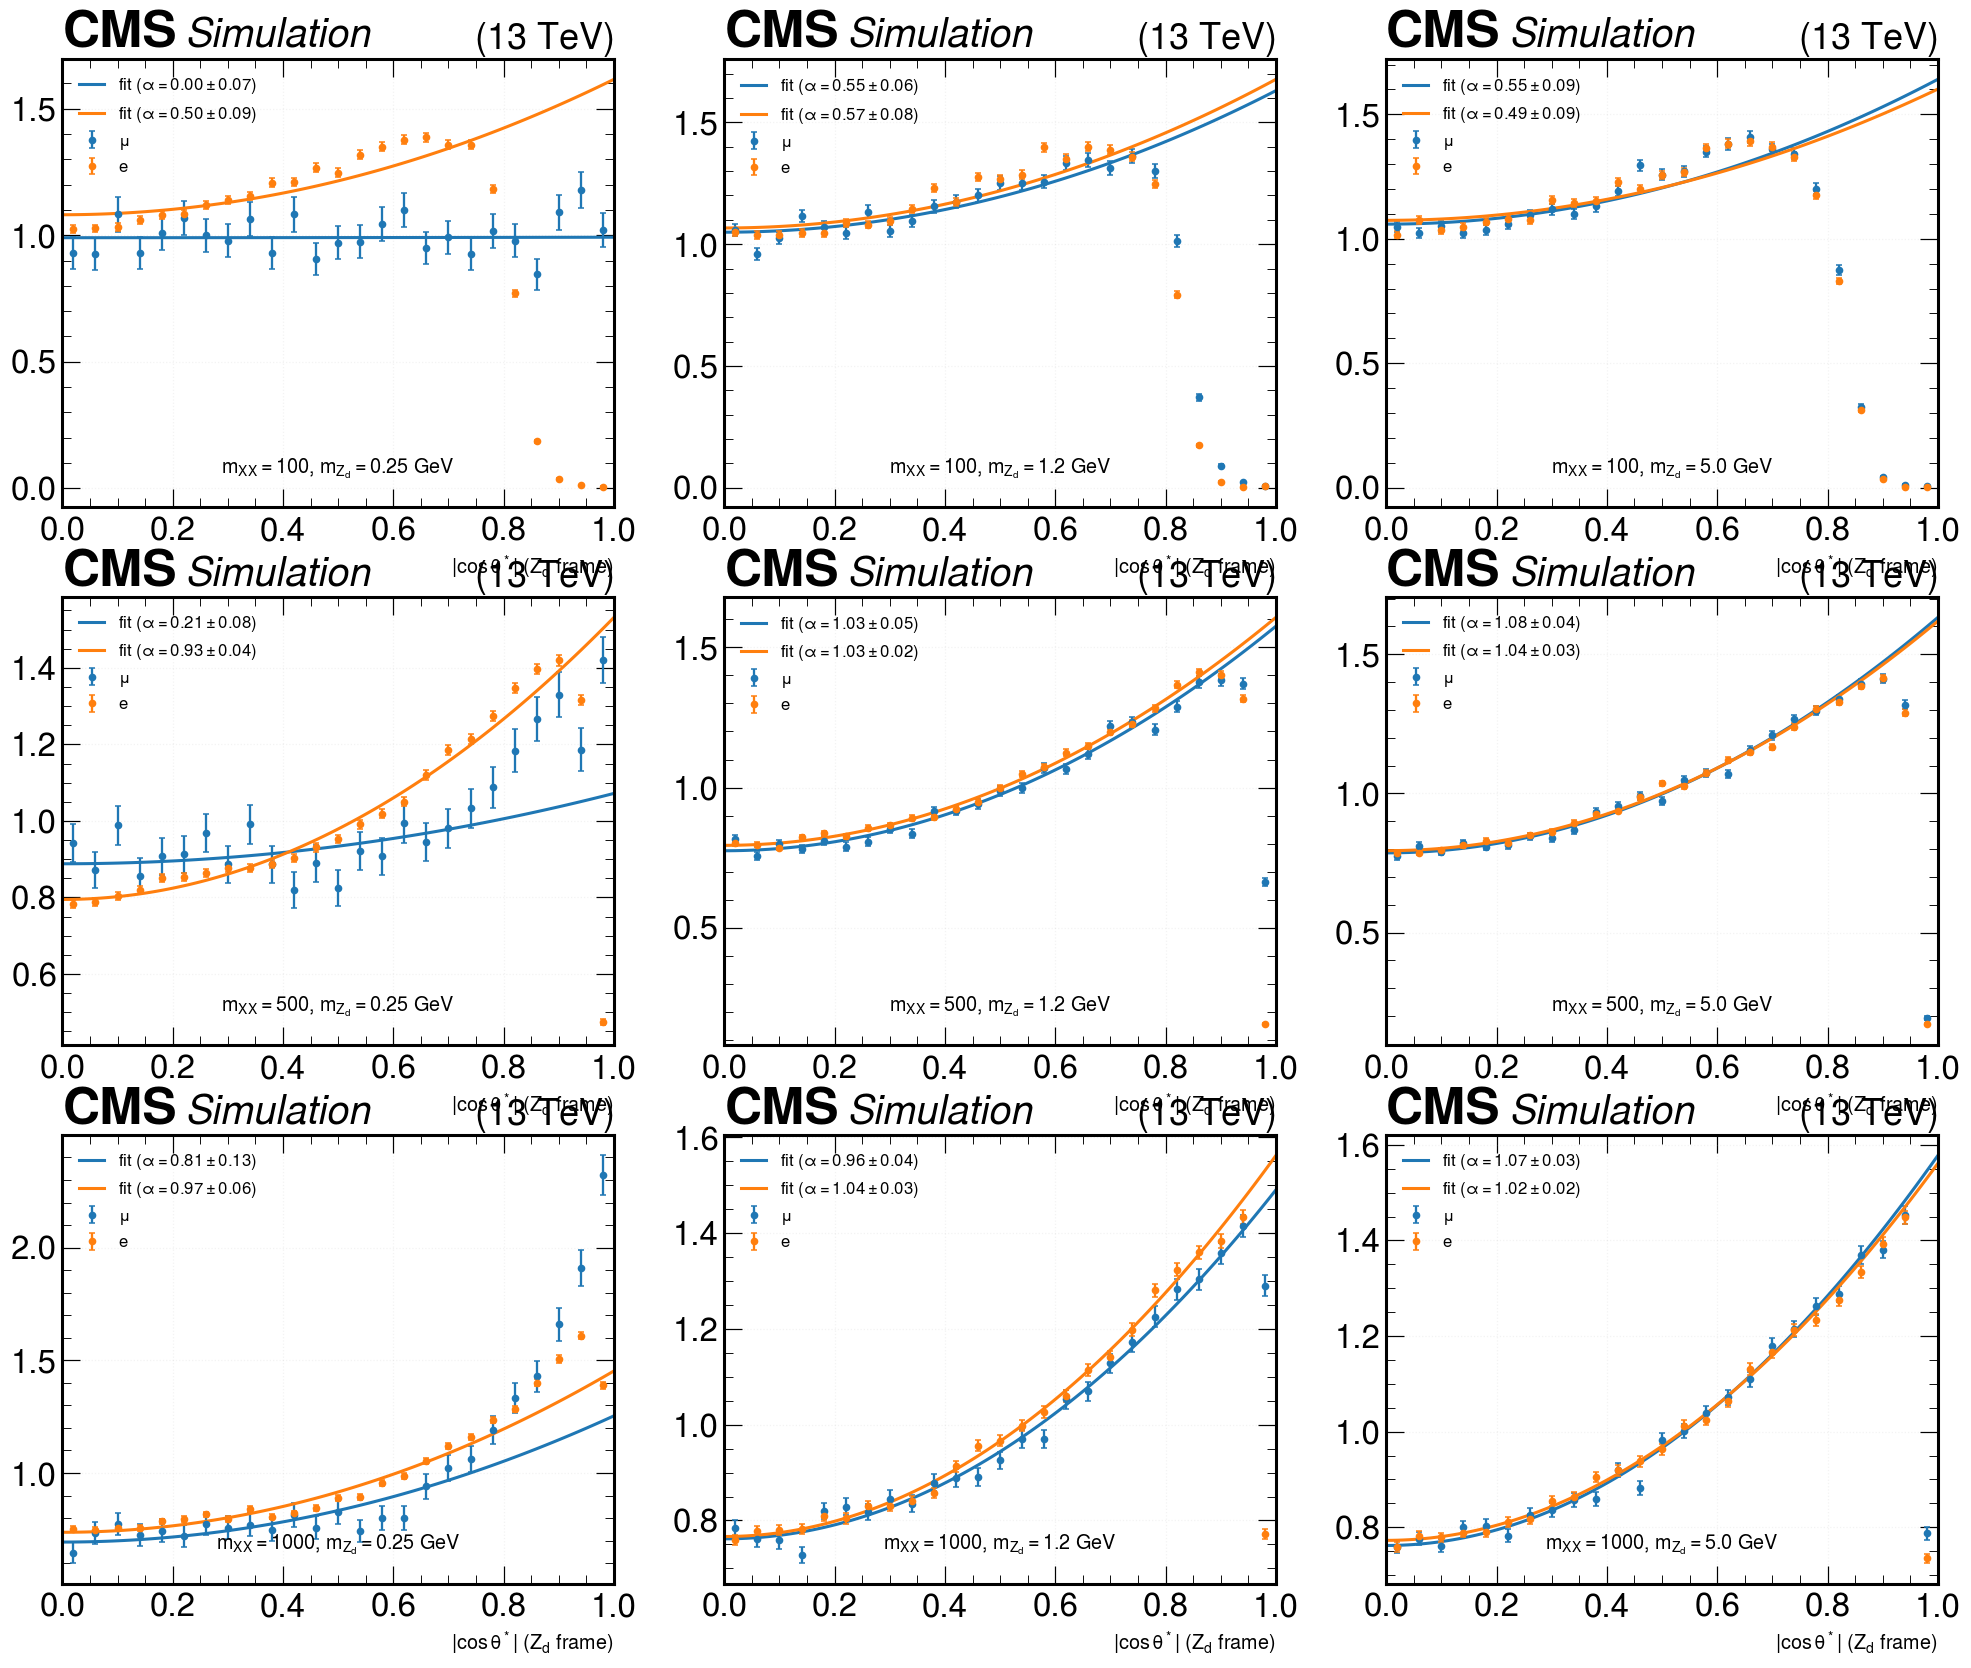

In [4]:
def fit_and_plot_polarization(h, ax, color, label_prefix, fit_range=(0.0, 0.8)):
    edges = h.axes[-1].edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    raw = h.values().flatten().astype(float)
    n = min(len(raw), len(centers))
    raw, centers = raw[:n], centers[:n]
    widths = (edges[1:] - edges[:-1])[:n]
    scale = 1.0 / max(np.sum(raw * widths), 1e-12)
    y, yerr = raw * scale, np.sqrt(raw) * scale
    yerr_safe = np.where(yerr == 0, scale, yerr)
    ax.errorbar(centers, y, yerr=yerr, fmt="o", markersize=4, color=color,
                capsize=2, label=label_prefix)
    mask = (centers >= fit_range[0]) & (centers <= fit_range[1])
    def spin1(x, A, alpha): return A * (1 + alpha * x**2)
    try:
        popt, pcov = opt.curve_fit(spin1, centers[mask], y[mask],
                                   sigma=yerr_safe[mask], p0=[max(y.max(), 1e-3), 0.5])
        perr = np.sqrt(np.diag(pcov))
        x_m = np.linspace(0, 1, 100)
        ax.plot(x_m, spin1(x_m, *popt), "-", color=color, lw=2,
                label=rf"fit ($\alpha={popt[1]:.2f}\pm{perr[1]:.2f}$)")
    except Exception:
        pass

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
for i, mxx in enumerate(BS_MASSES):
    for j, mzd in enumerate(ZD_MASSES):
        ax = axes[i, j]
        sample = SAMPLE_GRID[mxx][mzd]
        fit_and_plot_polarization(
            output[sample]["hists"]["genMu_AFrame_absCosTheta"][{"channel": CH_BORN}],
            ax, "tab:blue", r"$\mu$")
        fit_and_plot_polarization(
            output[sample]["hists"]["genE_AFrame_absCosTheta"][{"channel": CH_BORN}],
            ax, "tab:orange", r"$e$")
        ax.set_xlabel(r"$|\cos\theta^*|$ ($Z_d$ frame)", fontsize=13)
        ax.set_xlim(0, 1.0)
        ax.text(0.5, 0.06, sample_label(mxx, mzd), transform=ax.transAxes,
                ha="center", va="bottom", fontsize=13)
        ax.grid(True, alpha=0.15)
        ax.legend(loc="upper left", fontsize=11)
        hep.cms.label(ax=ax, data=False)
an_style.save(fig, "polarization_grid_born")


## Lepton reconstruction migration vs displacement

For each dark-photon decay, the number of nearby reconstructed electrons, photons, PF
muons, and DSA muons is histogrammed against the decay's `Lxy`, and each `Lxy` column is
normalized to the number of decays there, so every panel reads as "the fraction of dark
photon decays yielding N reconstructed objects of this type, at this displacement". The
migration the note describes in prose (GED electrons giving way to photons, PF muons to
DSA muons, as `Lxy` grows) is directly visible. Objects here pass the analysis LJ-source
definitions; the trigger is deliberately not applied.


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/reco_migration_1000GeV_0p25GeV.pdf


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/reco_migration_100GeV_5p0GeV.pdf


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/reco_migration_1000GeV_0p25GeV_noquality.pdf


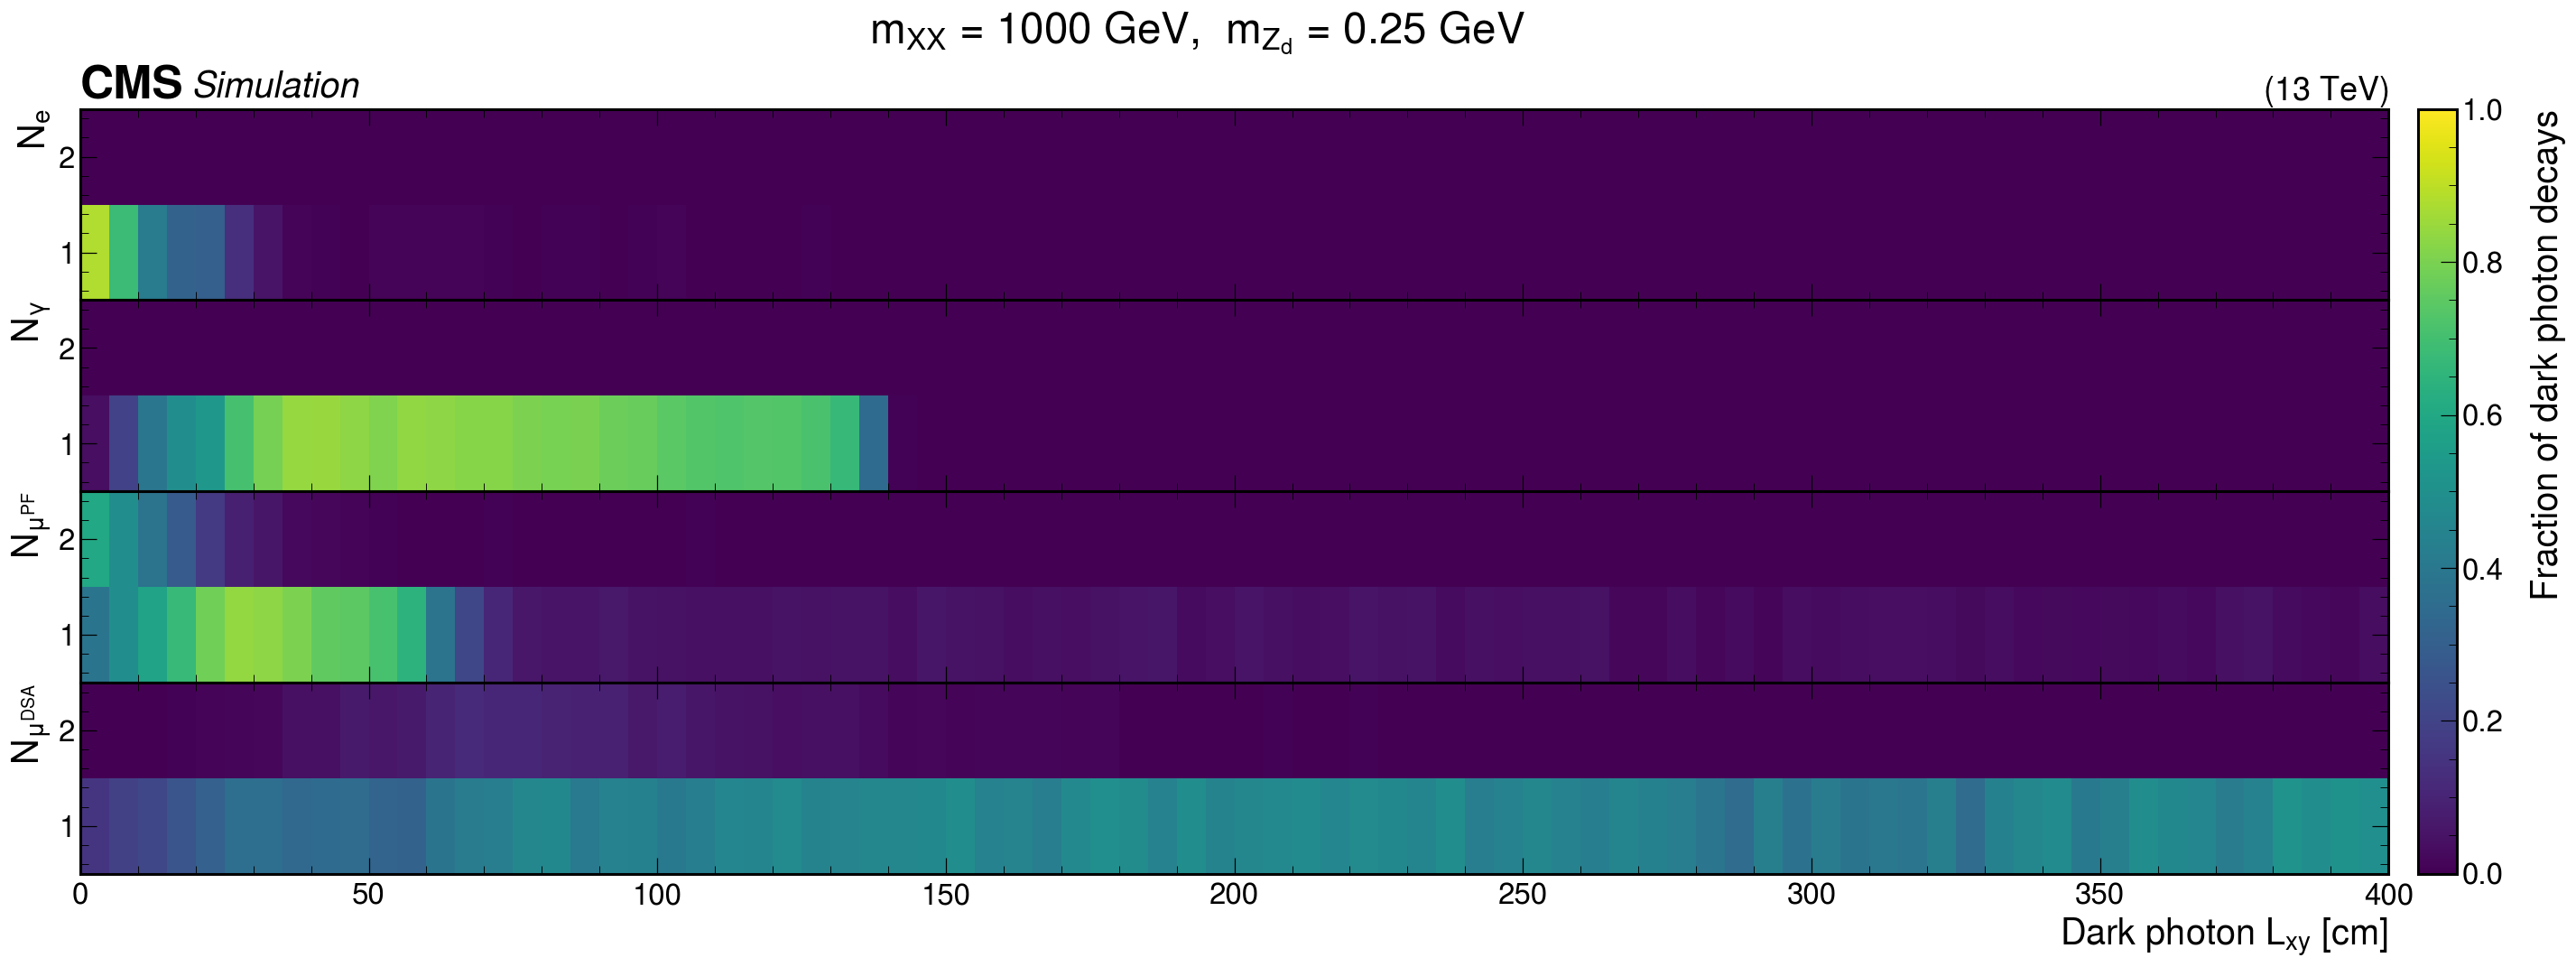

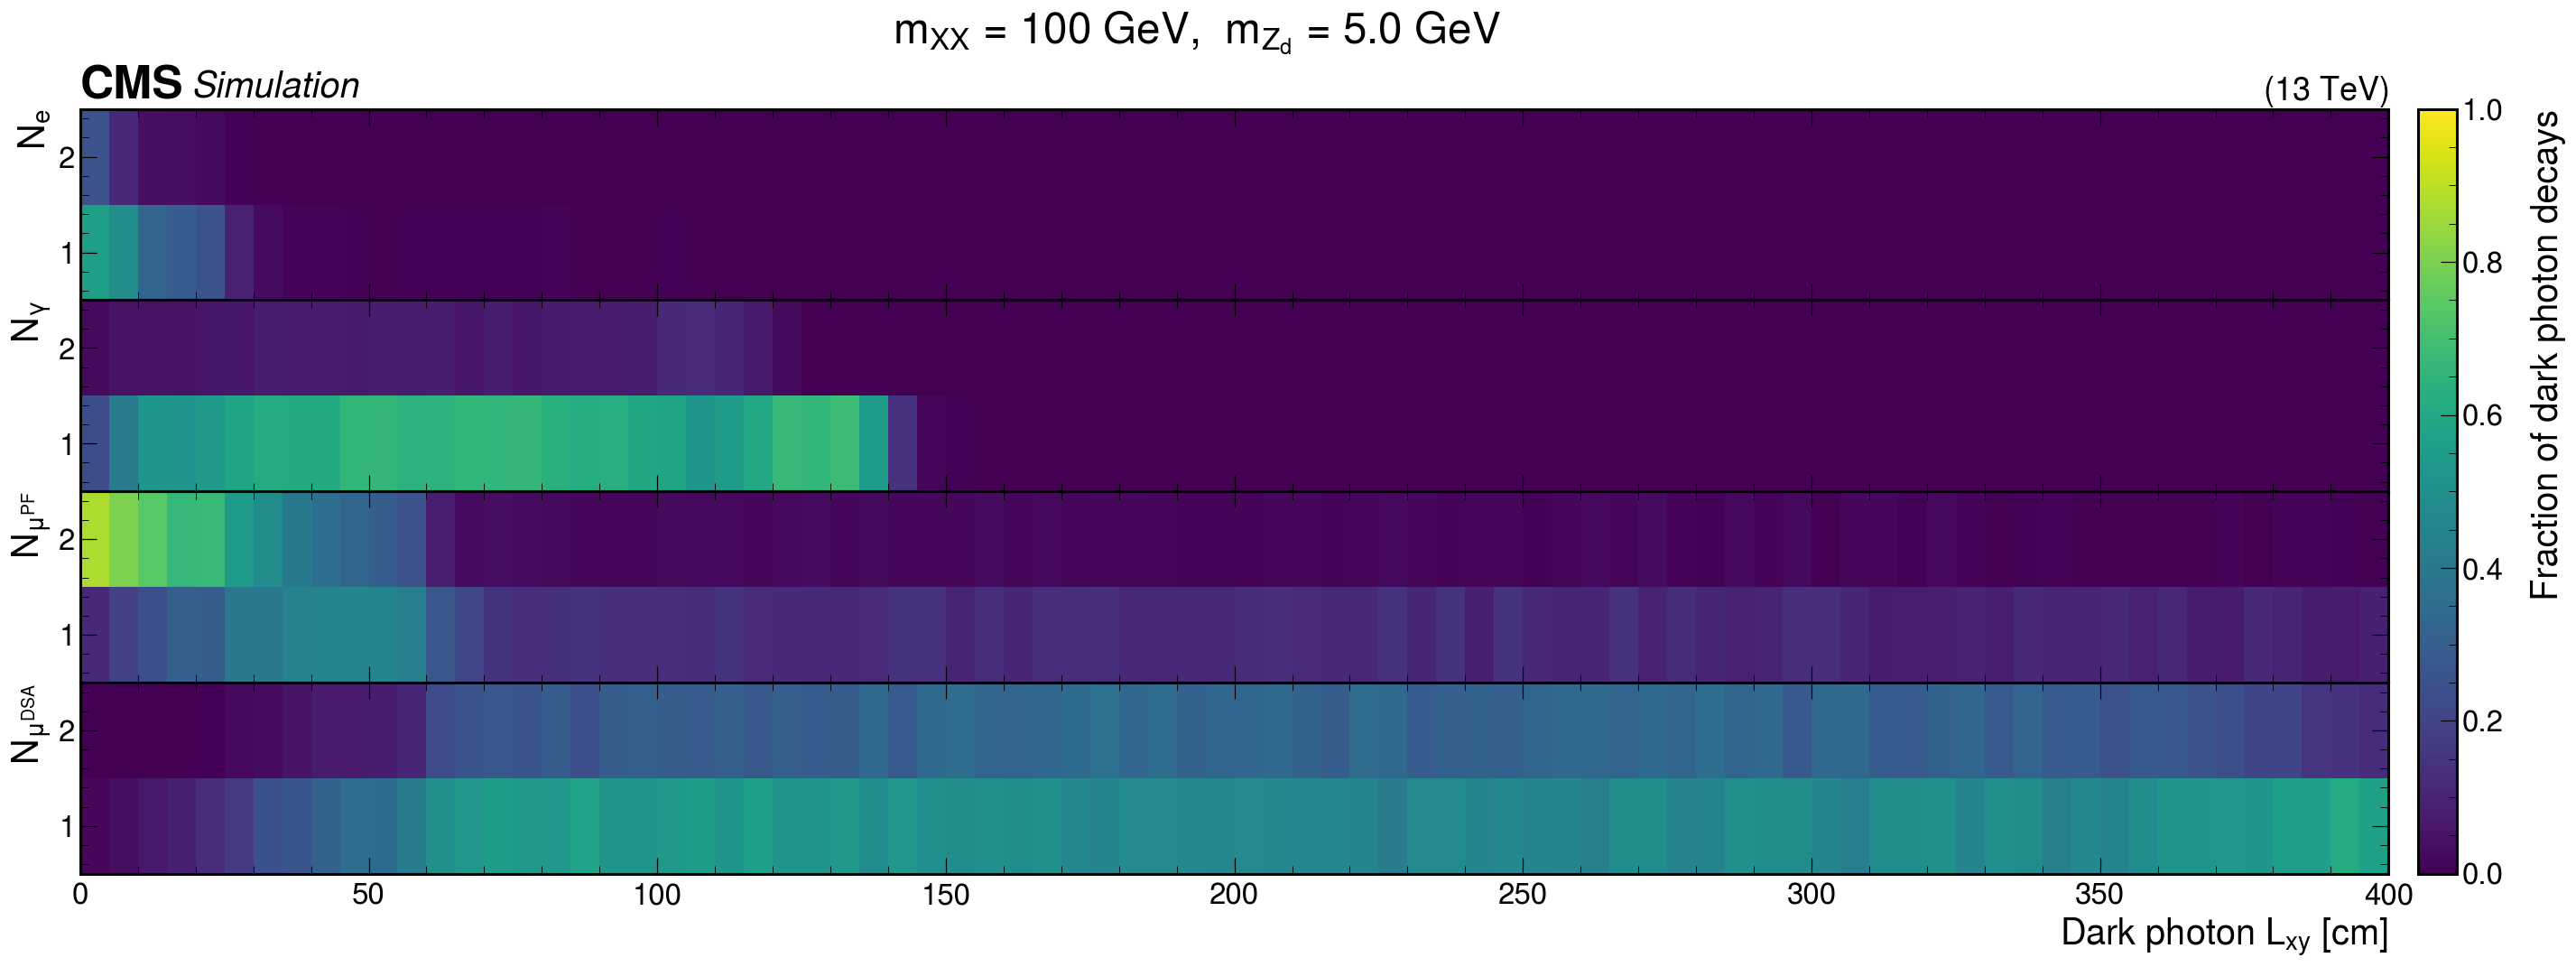

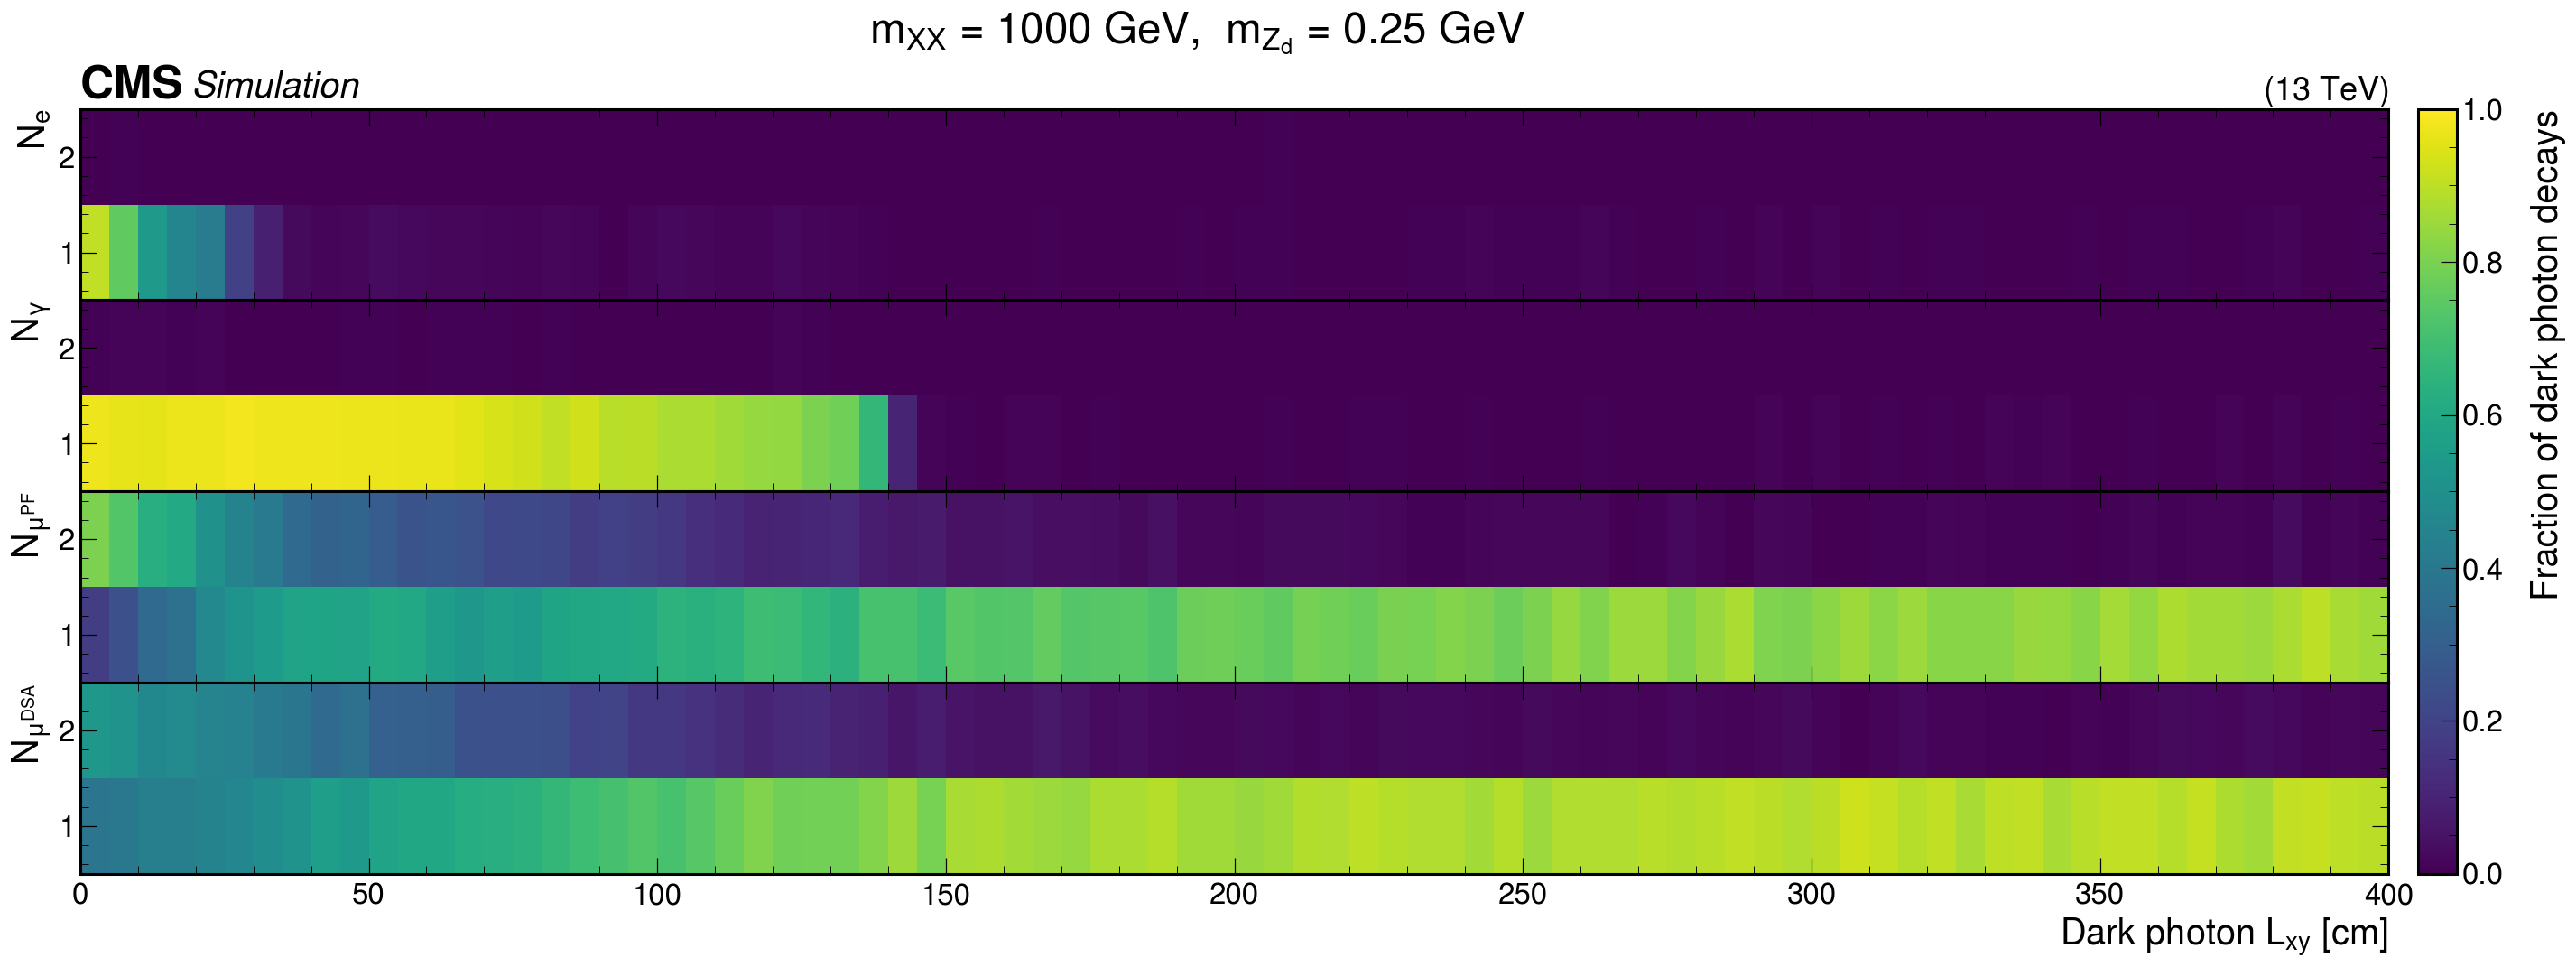

In [5]:
def make_eff(h):
    weights = 1 / np.sum(h.values(), axis=-1)
    weights = np.nan_to_num(weights)
    for ix in range(h.shape[1]):
        h[:, ix] = np.column_stack([h.values()[:, ix] * weights,
                                    h.variances()[:, ix] * weights**2])
    return h

def plot_single(h, channel, skip_label=True, remove_xlabel=True):
    h = h[{"channel": channel}]
    h = make_eff(h)
    utilities.plot(h[:400j, 1:3], skip_label=skip_label, cbar=False, cmax=1, flow="none")
    if remove_xlabel:
        plt.xlabel(None)
    plt.draw()

def plot_all_vs_lxy(sample, channel, tag):
    fig, ax = plt.subplots(4, 1, figsize=(30, 10), sharex=True)
    for k, obj in enumerate(["electron", "photon", "muon", "dsaMuon"]):
        plt.subplot(4, 1, k + 1)
        plot_single(output[sample]["hists"][f"{obj}_nearGenA_n_genA_lxy"], channel,
                    skip_label=(k != 0), remove_xlabel=(k != 3))
    fig.subplots_adjust(hspace=0, right=0.9)
    mxx, mzd = sample.split("_")[1:3]
    fig.suptitle(rf"$m_{{XX}}$ = {mxx.replace('GeV', ' GeV')},  "
                 rf"$m_{{Z_d}}$ = {mzd.replace('p', '.').replace('GeV', ' GeV')}")
    cax = fig.add_axes([0.91, 0.11, 0.013, 0.77])
    mappable = [c for a in fig.axes for c in a.collections][0]
    cb = fig.colorbar(mappable, cax=cax)
    cb.set_label("Fraction of dark photon decays", labelpad=20)
    an_style.save(fig, f"reco_migration_{tag}")

plot_all_vs_lxy("2Mu2E_1000GeV_0p25GeV_2p0mm", "baseNoLj_noTrigger", "1000GeV_0p25GeV")
plot_all_vs_lxy("2Mu2E_100GeV_5p0GeV_400mm", "baseNoLj_noTrigger", "100GeV_5p0GeV")
plot_all_vs_lxy("2Mu2E_1000GeV_0p25GeV_2p0mm", "baseNoLjNoLjsource_noTrigger",
                "1000GeV_0p25GeV_noquality")


## Summary

The canonical output reproduces the polarization structure of the original study at full
statistics: transverse polarization (`α` consistent with 1 at ~2σ) for
`m_XX ≥ 500 GeV, m_Zd ≥ 1.2 GeV`, muon velocity suppression at `m_Zd = 0.25 GeV`, and a
uniform depression of the `m_XX = 100 GeV` row for both flavors that carries the imprint
of the production gen filter's per-lepton `pT` requirement. The migration maps show the
reconstruction handoff (electron→photon, PF muon→DSA muon) as a function of displacement
with the analysis object definitions and no trigger, the truth-to-reconstruction bridge
the note's lepton-jet motivation rests on.
